In [2]:
from google.colab import files

uploaded = files.upload()

Saving hr_training_effectiveness_dataset.csv to hr_training_effectiveness_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("hr_training_effectiveness_dataset.csv")

df.head()

,Employee_ID,Department,Training_Status,Training_Duration,Course_Type,Training_Attendance,Pre_Training_Performance,Post_Training_Performance
0,EMP001,Finance,Trained,20,Technical,84.0,69.8,87.3
1,EMP002,Operations,Trained,8,Leadership,87.0,72.5,84.3
2,EMP003,Sales,Trained,24,Communication,97.0,70.2,85.5
3,EMP004,HR,Trained,20,Technical,79.0,82.6,94.3
4,EMP005,IT,Untrained,0,NaN,0.0,72.3,78.5


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (300, 8)

Column Names:
['Employee_ID', 'Department', 'Training_Status', 'Training_Duration', 'Course_Type', 'Training_Attendance', 'Pre_Training_Performance', 'Post_Training_Performance']

Data Types:
Employee_ID                   object
Department                    object
Training_Status               object
Training_Duration              int64
Course_Type                   object
Training_Attendance          float64
Pre_Training_Performance     float64
Post_Training_Performance    float64
dtype: object

Missing Values:
Employee_ID                   0
Department                    0
Training_Status               0
Training_Duration             0
Course_Type                  96
Training_Attendance           3
Pre_Training_Performance      0
Post_Training_Performance     0
dtype: int64

Duplicate Rows: 0

Statistical Summary:


,Training_Duration,Training_Attendance,Pre_Training_Performance,Post_Training_Performance
count,300.000000,297.000000,300.000000,300.000000
mean,14.086667,59.168350,70.012000,77.280333
std,13.681732,40.701185,10.000902,10.834976
min,0.000000,0.000000,41.500000,43.600000
25%,0.000000,0.000000,63.175000,69.900000
50%,12.000000,81.000000,69.900000,77.900000
75%,24.000000,90.000000,76.400000,84.325000
max,40.000000,100.000000,95.000000,100.000000


In [5]:
# Fill missing Course_Type
df["Course_Type"] = df["Course_Type"].fillna("Unknown")

# Fill missing attendance using median of trained employees
median_attendance = df.loc[
    df["Training_Status"] == "Trained",
    "Training_Attendance"
].median()

df["Training_Attendance"] = df["Training_Attendance"].fillna(
    median_attendance
)

# Remove duplicate rows
df = df.drop_duplicates()

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning:
Employee_ID                  0
Department                   0
Training_Status              0
Training_Duration            0
Course_Type                  0
Training_Attendance          0
Pre_Training_Performance     0
Post_Training_Performance    0
dtype: int64

Duplicate rows after cleaning: 0


In [6]:
df["Performance_Improvement"] = (
    df["Post_Training_Performance"]
    - df["Pre_Training_Performance"]
)

display(df.head())

,Employee_ID,Department,Training_Status,Training_Duration,Course_Type,Training_Attendance,Pre_Training_Performance,Post_Training_Performance,Performance_Improvement
0,EMP001,Finance,Trained,20,Technical,84.0,69.8,87.3,17.5
1,EMP002,Operations,Trained,8,Leadership,87.0,72.5,84.3,11.8
2,EMP003,Sales,Trained,24,Communication,97.0,70.2,85.5,15.3
3,EMP004,HR,Trained,20,Technical,79.0,82.6,94.3,11.7
4,EMP005,IT,Untrained,0,Unknown,0.0,72.3,78.5,6.2


In [7]:
print(df["Performance_Improvement"].describe())

count    300.000000
mean       7.268333
std        5.607159
min       -8.600000
25%        2.750000
50%        7.700000
75%       11.725000
max       19.600000
Name: Performance_Improvement, dtype: float64


In [8]:
comparison = df.groupby("Training_Status").agg(
    Employees=("Employee_ID", "count"),
    Avg_Pre_Performance=("Pre_Training_Performance", "mean"),
    Avg_Post_Performance=("Post_Training_Performance", "mean"),
    Avg_Improvement=("Performance_Improvement", "mean")
)

display(comparison.round(2))

,Employees,Avg_Pre_Performance,Avg_Post_Performance,Avg_Improvement
Training_Status,,,,
Trained,205,69.93,80.18,10.25
Untrained,95,70.20,71.03,0.83


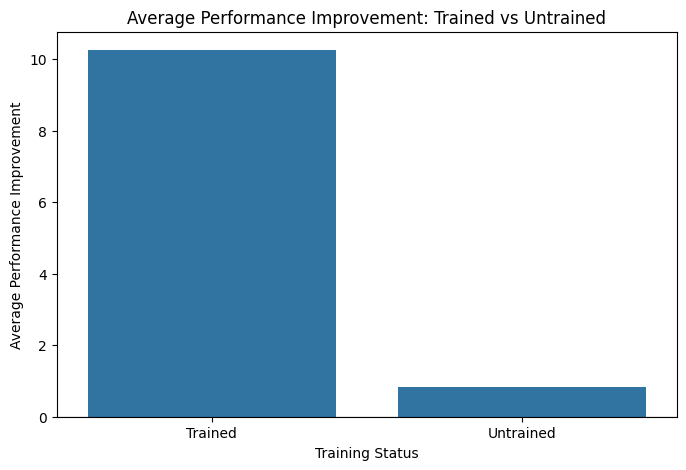

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Training_Status",
    y="Performance_Improvement",
    errorbar=None
)

plt.title("Average Performance Improvement: Trained vs Untrained")
plt.xlabel("Training Status")
plt.ylabel("Average Performance Improvement")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

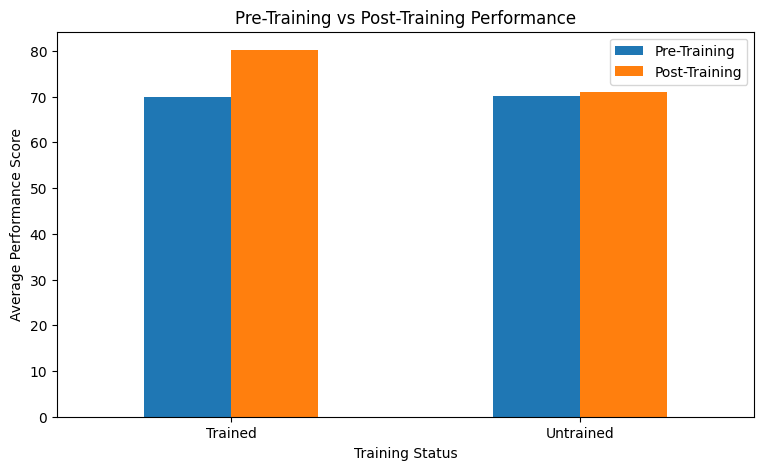

In [10]:
avg_performance = df.groupby("Training_Status")[
    ["Pre_Training_Performance", "Post_Training_Performance"]
].mean()

avg_performance.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Pre-Training vs Post-Training Performance")
plt.xlabel("Training Status")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=0)
plt.legend(["Pre-Training", "Post-Training"])
plt.show()

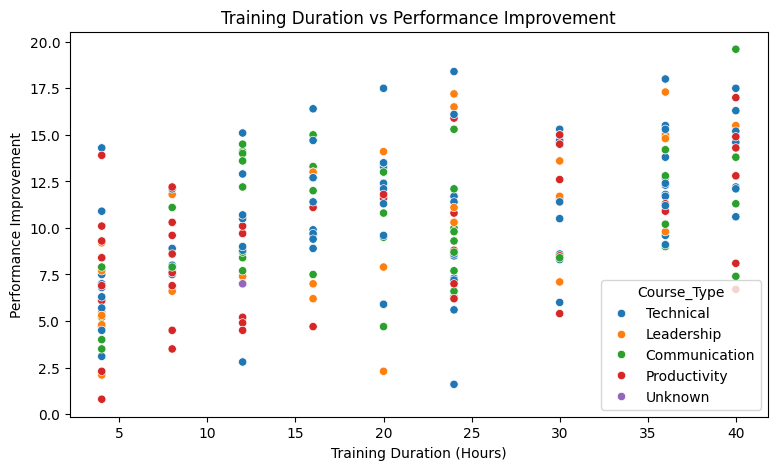

In [11]:
trained_df = df[df["Training_Status"] == "Trained"]

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=trained_df,
    x="Training_Duration",
    y="Performance_Improvement",
    hue="Course_Type"
)

plt.title("Training Duration vs Performance Improvement")
plt.xlabel("Training Duration (Hours)")
plt.ylabel("Performance Improvement")
plt.show()

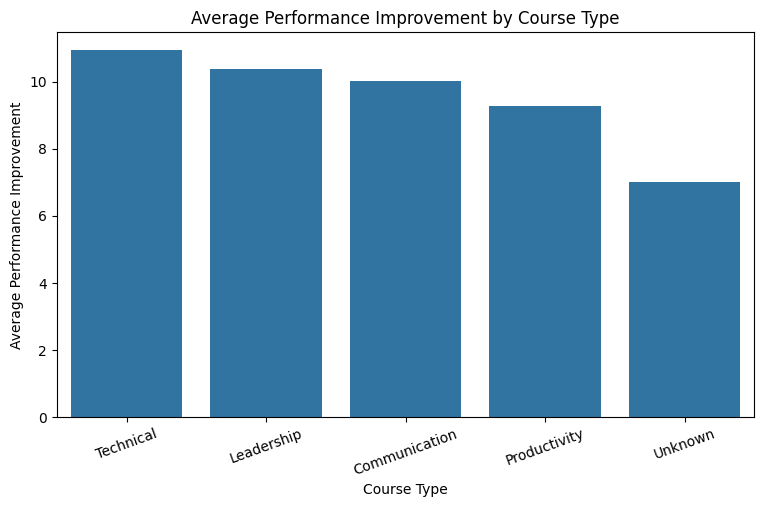

In [12]:
course_avg = trained_df.groupby("Course_Type")[
    "Performance_Improvement"
].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=course_avg.index,
    y=course_avg.values,
    errorbar=None
)

plt.title("Average Performance Improvement by Course Type")
plt.xlabel("Course Type")
plt.ylabel("Average Performance Improvement")
plt.xticks(rotation=20)
plt.show()

In [13]:
department_analysis = df.groupby("Department").agg(
    Employees=("Employee_ID", "count"),
    Avg_Pre_Performance=("Pre_Training_Performance", "mean"),
    Avg_Post_Performance=("Post_Training_Performance", "mean"),
    Avg_Improvement=("Performance_Improvement", "mean")
).sort_values("Avg_Improvement", ascending=False)

display(department_analysis.round(2))

,Employees,Avg_Pre_Performance,Avg_Post_Performance,Avg_Improvement
Department,,,,
Operations,53,67.72,76.75,9.03
Finance,44,70.92,79.10,8.18
Sales,70,69.04,75.72,6.68
HR,38,69.71,76.30,6.59
IT,95,71.70,78.27,6.57


In [14]:
attendance_analysis = trained_df[[
    "Training_Attendance",
    "Performance_Improvement"
]].corr()

display(attendance_analysis.round(2))

,Training_Attendance,Performance_Improvement
Training_Attendance,1.00,0.25
Performance_Improvement,0.25,1.00


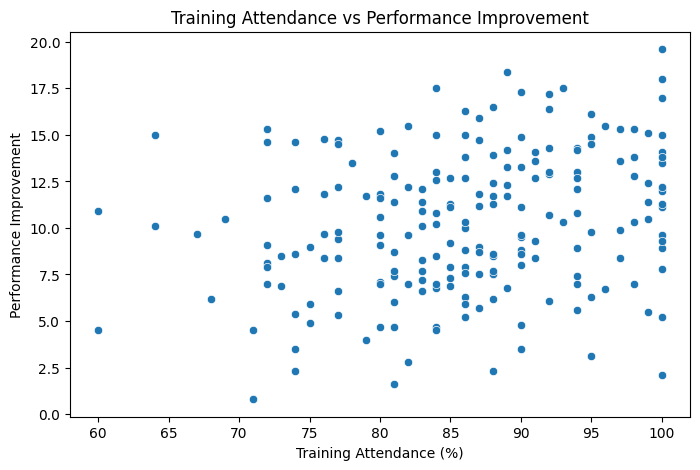

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=trained_df,
    x="Training_Attendance",
    y="Performance_Improvement"
)

plt.title("Training Attendance vs Performance Improvement")
plt.xlabel("Training Attendance (%)")
plt.ylabel("Performance Improvement")
plt.show()

In [16]:
duration_corr = trained_df[
    ["Training_Duration", "Performance_Improvement"]
].corr().iloc[0, 1]

print("Correlation between training duration and performance improvement:",
      round(duration_corr, 3))

Correlation between training duration and performance improvement: 0.495


In [17]:
def duration_group(hours):
    if hours <= 8:
        return "Short (≤8h)"
    elif hours <= 24:
        return "Medium (9–24h)"
    else:
        return "Long (>24h)"

trained_df = trained_df.copy()

trained_df["Duration_Group"] = trained_df[
    "Training_Duration"
].apply(duration_group)

duration_analysis = trained_df.groupby("Duration_Group").agg(
    Employees=("Employee_ID", "count"),
    Avg_Improvement=("Performance_Improvement", "mean")
)

display(duration_analysis.round(2))

,Employees,Avg_Improvement
Duration_Group,,
Long (>24h),63,12.43
Medium (9–24h),94,10.29
Short (≤8h),48,7.31


In [18]:
course_analysis = trained_df.groupby("Course_Type").agg(
    Employees=("Employee_ID", "count"),
    Avg_Attendance=("Training_Attendance", "mean"),
    Avg_Improvement=("Performance_Improvement", "mean")
).sort_values("Avg_Improvement", ascending=False)

display(course_analysis.round(2))

,Employees,Avg_Attendance,Avg_Improvement
Course_Type,,,
Technical,81,85.62,10.93
Leadership,32,89.00,10.38
Communication,45,87.71,10.01
Productivity,46,83.85,9.27
Unknown,1,72.00,7.00


In [19]:
course_analysis = trained_df.groupby("Course_Type").agg(
    Employees=("Employee_ID", "count"),
    Avg_Attendance=("Training_Attendance", "mean"),
    Avg_Improvement=("Performance_Improvement", "mean")
).sort_values("Avg_Improvement", ascending=False)

display(course_analysis.round(2))

,Employees,Avg_Attendance,Avg_Improvement
Course_Type,,,
Technical,81,85.62,10.93
Leadership,32,89.00,10.38
Communication,45,87.71,10.01
Productivity,46,83.85,9.27
Unknown,1,72.00,7.00


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Features
X = df[
    [
        "Department",
        "Training_Status",
        "Training_Duration",
        "Course_Type",
        "Training_Attendance",
        "Pre_Training_Performance"
    ]
]

# Target
y = df["High_Improvement"]

# Categorical and numerical columns
categorical_features = [
    "Department",
    "Training_Status",
    "Course_Type"
]

numerical_features = [
    "Training_Duration",
    "Training_Attendance",
    "Pre_Training_Performance"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

KeyError: 'High_Improvement'

In [21]:
# Create Performance Improvement if not already present
df["Performance_Improvement"] = (
    df["Post_Training_Performance"]
    - df["Pre_Training_Performance"]
)

# Create ML target
df["High_Improvement"] = (
    df["Performance_Improvement"] >= 10
).astype(int)

print(df[[
    "Pre_Training_Performance",
    "Post_Training_Performance",
    "Performance_Improvement",
    "High_Improvement"
]].head(10))

   Pre_Training_Performance  Post_Training_Performance  \
0                      69.8                       87.3   
1                      72.5                       84.3   
2                      70.2                       85.5   
3                      82.6                       94.3   
4                      72.3                       78.5   
5                      66.7                       67.1   
6                      72.2                       80.1   
7                      72.4                       86.2   
8                      68.5                       63.6   
9                      68.4                       73.6   

   Performance_Improvement  High_Improvement  
0                     17.5                 1  
1                     11.8                 1  
2                     15.3                 1  
3                     11.7                 1  
4                      6.2                 0  
5                      0.4                 0  
6                      7.9      

In [22]:
print(df["High_Improvement"].value_counts())

High_Improvement
0    195
1    105
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

X = df[
    [
        "Department",
        "Training_Status",
        "Training_Duration",
        "Course_Type",
        "Training_Attendance",
        "Pre_Training_Performance"
    ]
]

y = df["High_Improvement"]

categorical_features = [
    "Department",
    "Training_Status",
    "Course_Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ))
    ]
)

model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")

✅ Decision Tree trained successfully!


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.767
Precision: 0.684
Recall   : 0.619
F1 Score : 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        39
           1       0.68      0.62      0.65        21

    accuracy                           0.77        60
   macro avg       0.74      0.73      0.74        60
weighted avg       0.76      0.77      0.76        60



In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.767
Precision: 0.684
Recall   : 0.619
F1 Score : 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        39
           1       0.68      0.62      0.65        21

    accuracy                           0.77        60
   macro avg       0.74      0.73      0.74        60
weighted avg       0.76      0.77      0.76        60



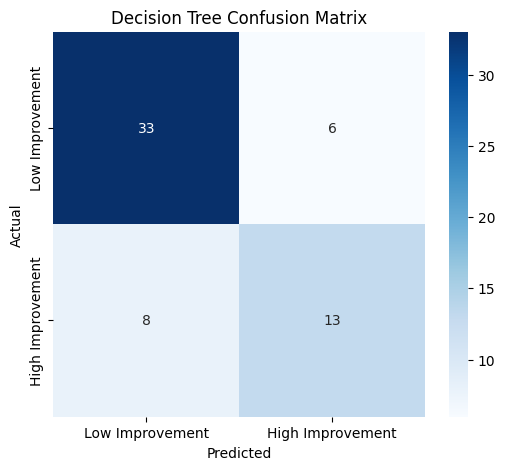

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Improvement", "High Improvement"],
    yticklabels=["Low Improvement", "High Improvement"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
12,remainder__Training_Duration,0.612375
13,remainder__Training_Attendance,0.138916
14,remainder__Pre_Training_Performance,0.109431
2,cat__Department_IT,0.045891
10,cat__Course_Type_Technical,0.045601
4,cat__Department_Sales,0.038229
7,cat__Course_Type_Communication,0.009557
6,cat__Training_Status_Untrained,0.000000
5,cat__Training_Status_Trained,0.000000
3,cat__Department_Operations,0.000000


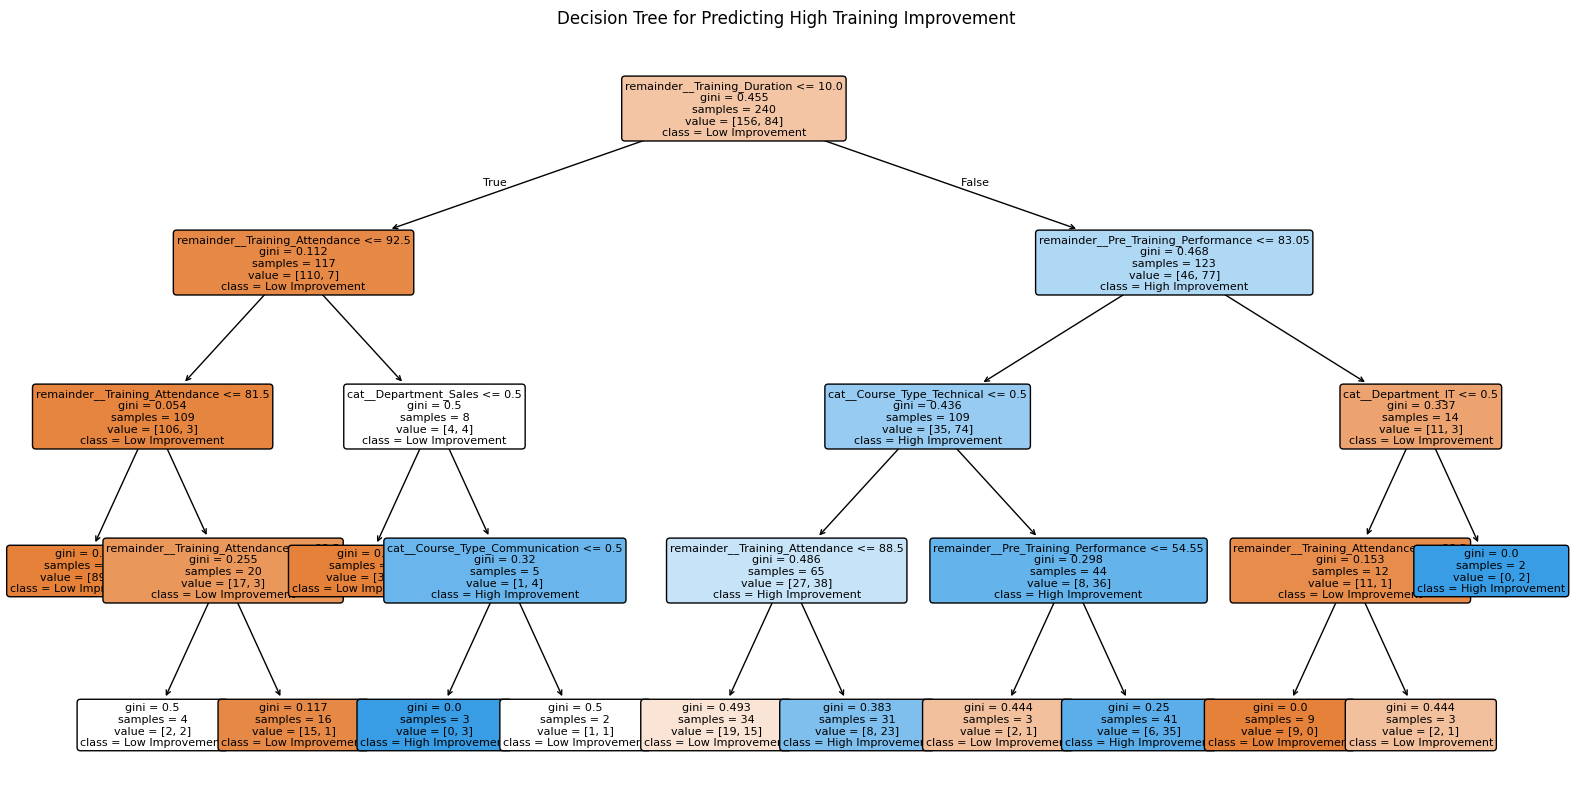

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Low Improvement", "High Improvement"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Predicting High Training Improvement")
plt.show()

In [29]:
# Final trained vs untrained comparison
final_comparison = df.groupby("Training_Status").agg(
    Employees=("Employee_ID", "count"),
    Avg_Pre=("Pre_Training_Performance", "mean"),
    Avg_Post=("Post_Training_Performance", "mean"),
    Avg_Improvement=("Performance_Improvement", "mean")
).round(2)

print("TRAINING STATUS COMPARISON")
display(final_comparison)

print("DEPARTMENT ANALYSIS")
display(
    df.groupby("Department")["Performance_Improvement"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "Employees",
          "mean": "Avg_Improvement"
      })
      .round(2)
)

print("COURSE TYPE ANALYSIS")
display(
    trained_df.groupby("Course_Type")["Performance_Improvement"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "Employees",
          "mean": "Avg_Improvement"
      })
      .round(2)
)

TRAINING STATUS COMPARISON


,Employees,Avg_Pre,Avg_Post,Avg_Improvement
Training_Status,,,,
Trained,205,69.93,80.18,10.25
Untrained,95,70.20,71.03,0.83


DEPARTMENT ANALYSIS


,Employees,Avg_Improvement
Department,,
Finance,44,8.18
HR,38,6.59
IT,95,6.57
Operations,53,9.03
Sales,70,6.68


COURSE TYPE ANALYSIS


,Employees,Avg_Improvement
Course_Type,,
Communication,45,10.01
Leadership,32,10.38
Productivity,46,9.27
Technical,81,10.93
Unknown,1,7.00


In [30]:
# Save cleaned dataset
df.to_csv("cleaned_hr_training_effectiveness_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [31]:
# Final Decision Tree evaluation results

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Score"] = results["Score"].round(3)

display(results)

NameError: name 'accuracy' is not defined

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate and store metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Final results table
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Score"] = results["Score"].round(3)

display(results)

,Metric,Score
0,Accuracy,0.767
1,Precision,0.684
2,Recall,0.619
3,F1 Score,0.650


In [33]:
import joblib

joblib.dump(model, "hr_training_decision_tree.pkl")

print("Decision Tree model saved successfully!")

Decision Tree model saved successfully!
